In [1]:
#Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

# Qiskit imports
from qiskit.circuit.library import ZZFeatureMap
from qiskit.primitives import StatevectorSampler
from qiskit_algorithms.state_fidelities import ComputeUncompute
from qiskit_machine_learning.kernels import FidelityQuantumKernel
from qiskit_machine_learning.algorithms import QSVR

In [2]:
#Metric calculation functions

def smape(y_true, y_pred):
    """Symmetric MAPE, avoids blow-ups near zero."""
    return 100/len(y_true) * np.sum(
        2 * np.abs(y_pred - y_true) /
        (np.abs(y_true) + np.abs(y_pred) + 1e-3)
    )

def print_metrics(label, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    smape_val = smape(y_true, y_pred)
    print(f"\n{label}: RMSE={rmse:.2f}, R²={r2:.4f}, SMAPE={smape_val:.2f}%")
    return {"rmse": rmse, "r2": r2, "smape": smape_val}


In [3]:
# Load & preprocess dataset


Wind = pd.read_csv(r"Wind_Turbin_Dataset.csv")
Wind.columns = ["Date", "ActivePower", "WindSpeed", "TheoreticalPower", "WindDirection"]
Wind = Wind.dropna()

# Date parsing
Wind["Date"] = pd.to_datetime(
    Wind["Date"], format="%d %m %Y %H:%M", dayfirst=True, errors="coerce"
)
Wind = Wind.dropna(subset=["Date"])

# Feature engineering
Wind["Hour"] = Wind["Date"].dt.hour
Wind["Month"] = Wind["Date"].dt.month

X = Wind[["WindSpeed", "TheoreticalPower", "WindDirection", "Hour", "Month"]].values
y = Wind["ActivePower"].values.astype(float)



print("✅ Data loaded. Shape:", X.shape)
Wind.head()

✅ Data loaded. Shape: (50530, 5)


,Date,ActivePower,WindSpeed,TheoreticalPower,WindDirection,Hour,Month
0,2018-01-01 00:00:00,380.047791,5.311336,416.328908,259.994904,0,1
1,2018-01-01 00:10:00,453.769196,5.672167,519.917511,268.641113,0,1
2,2018-01-01 00:20:00,306.376587,5.216037,390.900016,272.564789,0,1
3,2018-01-01 00:30:00,419.645905,5.659674,516.127569,271.258087,0,1
4,2018-01-01 00:40:00,380.650696,5.577941,491.702972,265.674286,0,1


In [4]:
# Split Edge & HPC dataset

X_hpc = X[:300]; y_hpc = y[:300]      # HPC uses first 500
X_edge = X[-100:]; y_edge = y[-100:]  # Edge uses last 100
# Train/test splits
X_hpc_train, y_hpc_train = X_hpc[:240], y_hpc[:240]
X_hpc_val,   y_hpc_val   = X_hpc[240:], y_hpc[240:]

X_edge_train, y_edge_train = X_edge[:80], y_edge[:80]
X_edge_test,  y_edge_test  = X_edge[80:], y_edge[80:]

In [5]:
# Scaling
scaler = StandardScaler()
X_hpc_train_s = scaler.fit_transform(X_hpc_train)
X_hpc_val_s   = scaler.transform(X_hpc_val)
X_edge_train_s = scaler.transform(X_edge_train)
X_edge_test_s  = scaler.transform(X_edge_test)


Edge Linear Regression (Edge test): RMSE=171.54, R²=0.9183, SMAPE=5.96%


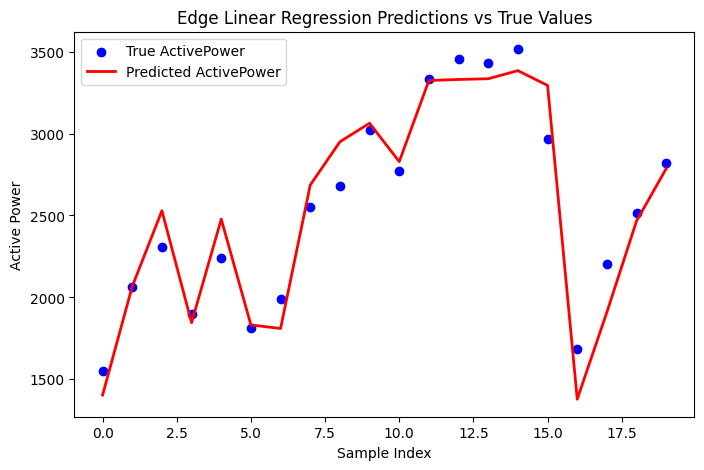

In [6]:
# Edge model (Linear Regression)

edge_model = LinearRegression()
edge_model.fit(X_edge_train_s, y_edge_train)
y_edge_pred = edge_model.predict(X_edge_test_s)
metrics_edge = print_metrics("Edge Linear Regression (Edge test)", y_edge_test, y_edge_pred)

# Edge predictions on HPC validation
edge_val_pred = edge_model.predict(X_hpc_val_s)


# Plot Edge 

plt.figure(figsize=(8,5))
plt.scatter(range(len(y_edge_test)), y_edge_test, color='blue', label='True ActivePower')
plt.plot(range(len(y_edge_test)), y_edge_pred, color='red', linewidth=2, label='Predicted ActivePower')
plt.xlabel("Sample Index")
plt.ylabel("Active Power")
plt.title("Edge Linear Regression Predictions vs True Values")
plt.legend()
plt.show()


In [7]:

# HPC (Quantum SVR)

sampler = StatevectorSampler()
fidelity = ComputeUncompute(sampler=sampler)

# Fixed hyperparameters
C = 0.1
eps = 0.01
reps = 1

best_results = {
    "quantum_only": {"r2": -np.inf},
    "hybrid": {"r2": -np.inf}
}

print(f"\n🔍 Testing C={C}, epsilon={eps}, reps={reps}")

# Build feature map
feature_map = ZZFeatureMap(
    feature_dimension=X_hpc_train_s.shape[1],
    reps=reps,
    entanglement="linear"
)

qkernel = FidelityQuantumKernel(
    feature_map=feature_map,
    fidelity=fidelity
)

qsvr = QSVR(quantum_kernel=qkernel, C=C, epsilon=eps)


qsvr.fit(X_hpc_train_s, y_hpc_train)
y_q_before = qsvr.predict(X_hpc_val_s)
metrics_before = print_metrics(
    f"QHPC QSVR (C={C}, eps={eps}, reps={reps}, before help)",
    y_hpc_val, y_q_before
)

if metrics_before["r2"] > best_results["quantum_only"]["r2"]:
    best_results["quantum_only"] = {
        "C": C, "epsilon": eps, "reps": reps, **metrics_before
    }



🔍 Testing C=0.1, epsilon=0.01, reps=1

QHPC QSVR (C=0.1, eps=0.01, reps=1, before help): RMSE=1016.62, R²=-0.0546, SMAPE=35.73%


In [8]:
# Hybrid (Edge+HPC)

edge_train_pred = edge_model.predict(X_hpc_train_s)
residuals_train = y_hpc_train - edge_train_pred

# Normalize residuals
residuals_mean, residuals_std = residuals_train.mean(), residuals_train.std()
residuals_train_norm = (residuals_train - residuals_mean) / residuals_std

# Train on residuals
qsvr.fit(X_hpc_train_s, residuals_train_norm)

resid_pred_val_norm = qsvr.predict(X_hpc_val_s)
resid_pred_val = resid_pred_val_norm * residuals_std + residuals_mean

y_q_after = edge_val_pred + resid_pred_val
metrics_after = print_metrics(
    f"QHPC QSVR (C={C}, eps={eps}, reps={reps}, after help)",
    y_hpc_val, y_q_after
)

if metrics_after["r2"] > best_results["hybrid"]["r2"]:
    best_results["hybrid"] = {
        "C": C, "epsilon": eps, "reps": reps, **metrics_after
    }



QHPC QSVR (C=0.1, eps=0.01, reps=1, after help): RMSE=582.01, R²=0.6544, SMAPE=22.37%



================ BEST RESULTS ================
Quantum-only best: {'C': 0.1, 'epsilon': 0.01, 'reps': 1, 'rmse': np.float64(1016.6209893668649), 'r2': -0.054569359480573176, 'smape': np.float64(35.7297452215147)}
Hybrid best: {'C': 0.1, 'epsilon': 0.01, 'reps': 1, 'rmse': np.float64(582.0071148057989), 'r2': 0.654368280228254, 'smape': np.float64(22.3711814550255)}


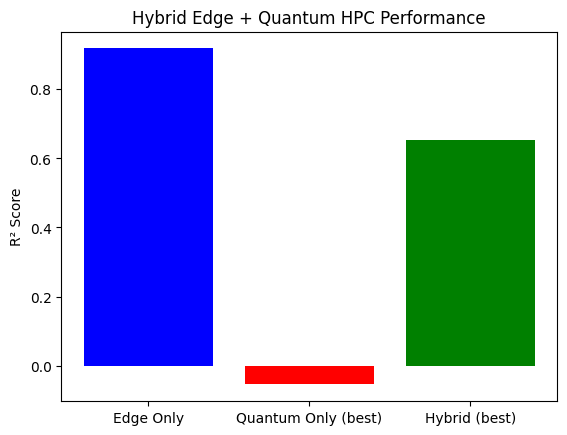

In [9]:
# Plot

print("\n================ BEST RESULTS ================")
print("Quantum-only best:", best_results["quantum_only"])
print("Hybrid best:", best_results["hybrid"])

# --------------------------
# Compare Edge vs Best Quantum vs Best Hybrid
# --------------------------
r2_edge = metrics_edge["r2"]
r2_quantum = best_results["quantum_only"]["r2"]
r2_hybrid = best_results["hybrid"]["r2"]

plt.bar(["Edge Only", "Quantum Only (best)", "Hybrid (best)"],
        [r2_edge, r2_quantum, r2_hybrid],
        color=["blue", "red", "green"])
plt.ylabel("R² Score")
plt.title("Hybrid Edge + Quantum HPC Performance")
plt.show()

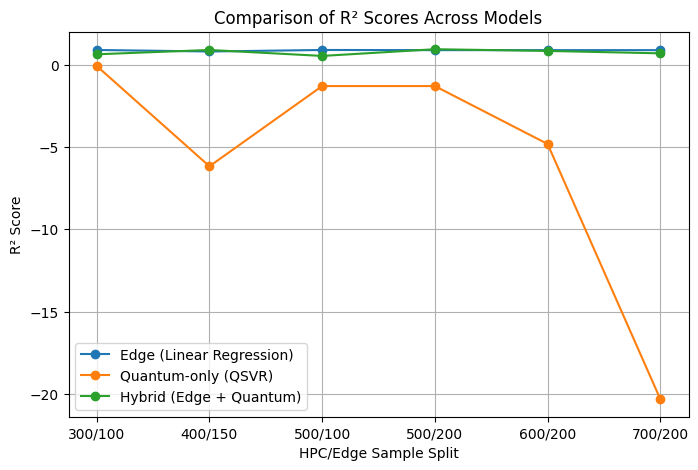

In [10]:
import matplotlib.pyplot as plt

models = ["300/100", "400/150", "500/100", "500/200" , "600/200", "700/200"]
edge_r2 = [0.9183, 0.8253, 0.9183, 0.9080, 0.9080, 0.9080]
quantum_r2 = [-0.0546, -6.1605, -1.2783, -1.2783, -4.8043, -20.3363]
hybrid_r2 = [0.6551, 0.9185, 0.5560, 0.9638, 0.8594, 0.7138]

plt.figure(figsize=(8,5))
plt.plot(models, edge_r2, marker='o', label="Edge (Linear Regression)")
plt.plot(models, quantum_r2, marker='o', label="Quantum-only (QSVR)")
plt.plot(models, hybrid_r2, marker='o', label="Hybrid (Edge + Quantum)")
plt.xlabel("HPC/Edge Sample Split")
plt.ylabel("R² Score")
plt.title("Comparison of R² Scores Across Models")
plt.legend()
plt.grid(True)
plt.show()